# Data Exploration and Preparation

## Dataset 3: COVID-FAQ / COUGH Dataset (SunLab, Ohio State University)

[Dataset3](https://github.com/sunlab-osu/covid-faq/tree/main/data)

### Data Description

#### **Dataset Origin and Context**

The COUGH (COVID-19 FAQ Retrieval) dataset is a well-established benchmark dataset designed specifically for FAQ retrieval and question answering tasks in the COVID-19 domain. It was introduced to support research in information retrieval, semantic matching, and public health question answering, particularly during the COVID-19 pandemic.
The FAQ_Bank.csv file represents the complete FAQ repository, containing 15,919 expert-curated FAQ items collected from authoritative health and government sources such as healthcare agencies, public health departments, and official medical organisations. Unlike conversational or forum-based data, this dataset focuses on non-forum, verified FAQ content, making it especially suitable for high-trust information systems.

#### **Dataset Structure**

The dataset consists of 9 columns, structured as follows:
- Column Name: Description
- index	Unique: identifier for each FAQ item
- url: Source URL of the FAQ
- question: COVID-19 related public health question
- original answer: Raw answer text (HTML-rich)
- answer wLink: Cleaned answer text with hyperlinks
- source: Publishing organisation (e.g., AHCCCS)
- language:	Language code (primarily English – en)
- type: Entry type (e.g., Question)

The dataset follows a Question–Answer (QA) structure, which aligns directly with the requirements of Retrieval-Augmented Generation (RAG) pipelines.

#### **Appropriateness for This Study**

This dataset is highly appropriate for your research for several reasons:
- Public Health Focus
  - All FAQs are framed for general users, not clinicians, aligning perfectly with your study’s emphasis on lay audiences.
- High Retrieval Complexity
  - Large FAQ bank (15k+ items)
  - Semantically overlapping questions
    → Ideal for evaluating advanced retrieval, re-ranking, and query optimisation
- Benchmark Relevance
  - COUGH is widely used in FAQ retrieval research, strengthening the academic credibility of your evaluation.
- RAG Compatibility
  - Clean QA pairs
  - Source attribution via URLs
  - Suitable for chunk-level citation grounding


### Statistical & Exploratory Analysis

In [1]:
# Import Required Libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import List, Dict

In [2]:
file_path3 = "/content/drive/MyDrive/MS-LJMU/Data/covid-faq-main/data/FAQ_Bank.csv"

In [4]:
df3 = pd.read_csv(file_path3)

In [5]:
df3.head()

,index,url,question,original answer,answer,answer wLink,source,language,type
0,0,https://www.azahcccs.gov/AHCCCS/AboutUs/covid1...,Does AHCCCS have a centralized resource for m...,"<dd><b>Answer: </b>Yes, the AHCCCS <a href=""/P...","Yes, the AHCCCS Medical Coding Resources webp...","Answer: Yes, the AHCCCS Medical Coding Resourc...",AHCCCS,en,Question
1,1,https://www.azahcccs.gov/AHCCCS/AboutUs/covid1...,Are there billing codes available for COVID-1...,<dd><b>Answer: </b>Yes. The Centers for Medica...,Yes. The Centers for Medicare & Medicaid Serv...,Answer: Yes. The Centers for Medicare & Medica...,AHCCCS,en,Question
2,2,https://www.azahcccs.gov/AHCCCS/AboutUs/covid1...,Will AHCCCS issue guidance regarding prior au...,<dd><b>Answer: </b>Prior authorization is not ...,Prior authorization is not permitted for COVI...,Answer: Prior authorization is not permitted f...,AHCCCS,en,Question
3,3,https://www.azahcccs.gov/AHCCCS/AboutUs/covid1...,Is there a claims modifier for services relat...,"<dd><b>Answer: </b>Yes, AHCCCS has designated ...","Yes, AHCCCS has designated the CR modifier to...","Answer: Yes, AHCCCS has designated the CR modi...",AHCCCS,en,Question
4,4,https://www.azahcccs.gov/AHCCCS/AboutUs/covid1...,Does AHCCCS cover testing for COVID-19?,"<dd><b>Answer: </b>Yes, AHCCCS covers COVID-19...","Yes, AHCCCS covers COVID-19 testing. HCPCS U0...","Answer: Yes, AHCCCS covers COVID-19 testing. H...",AHCCCS,en,Question


In [6]:
df3["language"].unique()

array(['en', 'es', 'ko', 'vi', 'zh', 'ar', 'fa', 'hy', 'kr', 'ja', 'fr',
       'ru', 'cs', 'de', 'hi', 'id', 'it', 'nl', 'pt', 'th'], dtype=object)

In [7]:
df3 = df3[df3["language"]=="en"] # Taking only english Q&A

In [8]:
df3 = df3.dropna() # Drop null values

In [9]:
# Basic Dataset Inspection


print("Dataset Shape:", df3.shape)

print("Columns:", df3.columns.tolist())

df3.isnull().sum()

Dataset Shape: (9148, 9)
Columns: ['index', 'url', 'question', 'original answer', 'answer', 'answer wLink', 'source', 'language', 'type']


,0
index,0
url,0
question,0
original answer,0
answer,0
answer wLink,0
source,0
language,0
type,0


In [10]:
df3["question"]

,question
0,Does AHCCCS have a centralized resource for m...
1,Are there billing codes available for COVID-1...
2,Will AHCCCS issue guidance regarding prior au...
3,Is there a claims modifier for services relat...
4,Does AHCCCS cover testing for COVID-19?
...,...
9146,Am I High Risk for Covid19? I am a diabetic wh...
9147,Am I High Risk for Covid19? I am a diabetic wh...
9148,Am I High Risk for Covid19? I am a diabetic wh...
9149,Children and grandparents. \n \n\n ...


In [12]:
df3["answer"]

,answer
0,"Yes, the AHCCCS Medical Coding Resources webp..."
1,Yes. The Centers for Medicare & Medicaid Serv...
2,Prior authorization is not permitted for COVI...
3,"Yes, AHCCCS has designated the CR modifier to..."
4,"Yes, AHCCCS covers COVID-19 testing. HCPCS U0..."
...,...
9146,Those who are higher risk of novel coronavirus...
9147,"Gosh, I'm sorry you went through that. I'm ve..."
9148,Do you have any remaining issues from the seps...
9149,If you have any children or grandparents artic...


In [13]:
df3["answer wLink"]

,answer wLink
0,"Answer: Yes, the AHCCCS Medical Coding Resourc..."
1,Answer: Yes. The Centers for Medicare & Medica...
2,Answer: Prior authorization is not permitted f...
3,"Answer: Yes, AHCCCS has designated the CR modi..."
4,"Answer: Yes, AHCCCS covers COVID-19 testing. H..."
...,...
9146,Those who are higher risk of novel coronavirus...
9147,"Gosh, I'm sorry you went through that. I'm ve..."
9148,Do you have any remaining issues from the seps...
9149,If you have any children or grandparents artic...


### Visualisations and Insights

In [14]:
# Token-Level Analysis (LLM-Aware)

import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

df3["question_tokens"] = df3["question"].apply(lambda x: len(enc.encode(x)))
df3["answer_tokens"] = df3["answer"].apply(lambda x: len(enc.encode(x)))

df3[["question_tokens", "answer_tokens"]].describe()

,question_tokens,answer_tokens
count,9148.000000,9148.000000
mean,55.762899,138.602317
std,121.483932,162.937438
min,1.000000,1.000000
25%,11.000000,62.000000
50%,16.000000,102.000000
75%,35.000000,161.000000
max,1557.000000,6134.000000


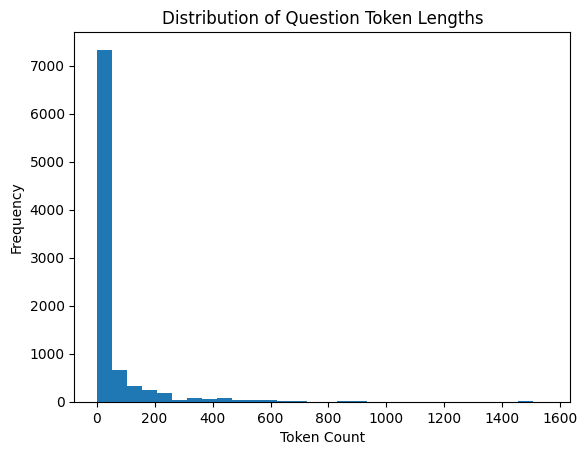

In [15]:
# Question Length Distribution

plt.figure()
plt.hist(df3["question_tokens"], bins=30)
plt.title("Distribution of Question Token Lengths")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

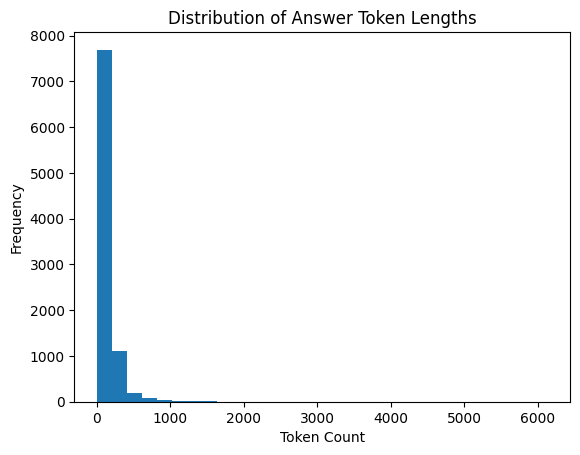

In [16]:
# Answer Length Distribution

plt.figure()
plt.hist(df3["answer_tokens"], bins=30)
plt.title("Distribution of Answer Token Lengths")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

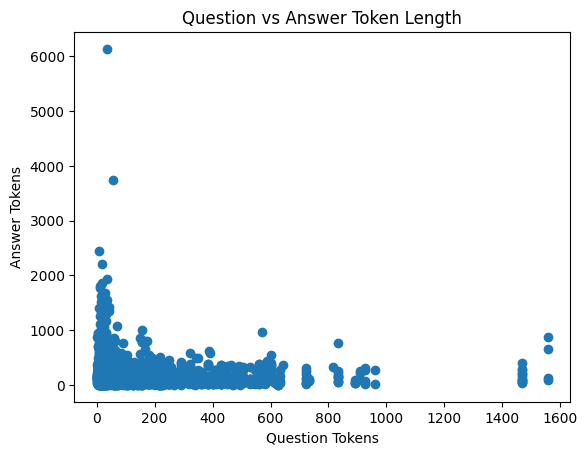

In [17]:
# Question vs Answer Length Relationship

plt.figure()
plt.scatter(df3["question_tokens"], df3["answer_tokens"])
plt.xlabel("Question Tokens")
plt.ylabel("Answer Tokens")
plt.title("Question vs Answer Token Length")
plt.show()

# Embedding Preparation

In [ ]:
EMBEDDING_MODEL = "text-embedding-3-large"
EMBEDDING_DIM = 3072

In [ ]:
def build_embedding_text(row):
    return f"""Question: {row['question']}

Answer: {row['answer']}"""

In [ ]:
!pip install langchain
!pip install openai
!pip install tiktoken

In [ ]:
!pip install -U langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

In [ ]:
def chunk_faq(row):
    chunks = splitter.split_text(row["answer"])
    documents = []

    for i, chunk in enumerate(chunks):
        text = f"""Question: {row['question']}

Answer (Part {i+1}): {chunk}"""
        documents.append((text, i))

    return documents

In [ ]:
from langchain_core.documents import Document

In [ ]:
documents = []

for _, row in df3.iterrows():
    chunks = chunk_faq(row)
    for text, chunk_id in chunks:
        metadata = {
            "faq_id": row["index"],
            "source": row["source"],
            "url": row["url"],
            "language": row["language"],
            "type": row["type"],
            "chunk_id": chunk_id,
            "dataset": "COUGH_FAQ"
        }

        documents.append(
            Document(
                page_content=text,
                metadata=metadata
            )
        )

In [ ]:
import tiktoken

encoding = tiktoken.encoding_for_model(EMBEDDING_MODEL)

def count_tokens(text: str) -> int:
    """
    Count tokens for a given text using tiktoken.
    """
    return len(encoding.encode(text))


def add_token_metadata(documents):
    """
    Adds token count to each Document's metadata.
    """
    for doc in documents:
        doc.metadata["embedding_tokens"] = count_tokens(doc.page_content)
    return documents

In [ ]:
documents = add_token_metadata(documents)

In [ ]:
documents[5]

Document(metadata={'faq_id': 1, 'source': 'AHCCCS', 'url': 'https://www.azahcccs.gov/AHCCCS/AboutUs/covid19FAQ.html', 'language': 'en', 'type': 'Question', 'chunk_id': 4, 'dataset': 'COUGH_FAQ', 'embedding_tokens': 63}, page_content='Question:  Are there billing codes available for COVID-19 testing outside of Centers for Disease Control and Prevention (CDC) testing laboratories?\n\nAnswer (Part 5): that would otherwise be identified by U0002. Neither U0003 nor U0004 should be used for tests that detect COVID-19 antibodies.')